#Differential Expression with DESeq2
   RNA-Sequence Analysis Workflow

1. Install packages and load libraries
2. Read gene counts and meta data into a data frame
3. Quality assess and clean raw sequencing data
4. Align reads to a reference
5. Count the number of reads assigned to each contig/gene
6. Extract counts and store in a matrix
7. Create column metadata table
8. Analyze count data using DESEQ2

`Sk. Tanzir Mehedi`

`Lecturer, Department of IT, UITS`


Install package `Biobase`

In [ ]:
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("Biobase")

Install package `DESeq2`

In [2]:
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("DESeq2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Bioconductor version 3.12 (BiocManager 1.30.10), R 4.0.4 (2021-02-15)

Installing package(s) 'BiocVersion', 'DESeq2'

also installing the dependencies ‘bit’, ‘bitops’, ‘formatR’, ‘bit64’, ‘plogr’, ‘RCurl’, ‘GenomeInfoDbData’, ‘zlibbioc’, ‘matrixStats’, ‘lambda.r’, ‘futile.options’, ‘RSQLite’, ‘XML’, ‘xtable’, ‘GenomeInfoDb’, ‘XVector’, ‘MatrixGenerics’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘AnnotationDbi’, ‘annotate’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘genefilter’, ‘locfit’, ‘geneplotter’, ‘RcppArmadillo’




Load libraries

In [2]:
library(DESeq2)
library(ggplot2)
library(dplyr)
library(readr)
library(RColorBrewer)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:parallel':

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min



Attaching package: 'S4Vectors'


The follow

Read gene counts data

In [3]:
countData <- read.csv('GSE57148_filtered_countdata.csv', header = TRUE, sep = ",")
head(countData)

,X,GSM1375986,GSM1375987,GSM1375988,GSM1375989,GSM1375990,GSM1375991,GSM1375992,GSM1375993,GSM1375994,...,GSM1376165,GSM1376166,GSM1376167,GSM1376168,GSM1376169,GSM1376170,GSM1376171,GSM1376172,GSM1376173,GSM1376174
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSPAN6,25.65762,31.55926,20.36529,16.18264,17.84060,26.21521,30.05497,55.86124,36.84434,...,26.59584,28.35389,23.02784,19.38732,19.30584,33.24688,34.78847,21.06747,22.31581,18.01265
2,TNMD,3.17695,0.03574,0.17943,0.00000,0.00000,0.08108,0.09071,0.03073,0.16547,...,0.06759,0.03367,0.36894,0.45659,0.00000,0.03587,0.05808,0.00000,0.00000,0.00000
3,DPM1,36.82232,34.16835,29.99469,36.69283,22.90644,32.64739,29.32929,42.46437,33.53497,...,34.74018,39.70218,29.91467,31.29367,32.33413,34.64562,33.62691,24.83168,28.07218,30.04324
4,SCYL3,11.80009,11.43711,25.47904,13.68362,13.93108,25.56658,26.36613,23.16797,22.11764,...,18.55288,23.57212,21.70581,26.97367,27.91776,19.00847,21.05312,20.64247,26.69223,12.69526
5,C1orf112,3.81234,3.53835,6.69872,5.66849,3.38641,3.70256,6.86366,3.01122,5.37773,...,3.31181,6.49917,6.79460,8.67512,7.57092,5.16456,5.37218,5.40347,4.92840,4.71918
6,FGR,45.65726,35.95540,68.09364,77.07324,118.00123,35.29594,90.31608,52.78856,74.68149,...,60.05185,47.41363,51.43601,81.20197,60.09416,66.99588,31.88459,115.65856,83.66457,108.87352


Check row and colums of gene counts data

In [4]:
ncol(countData)
nrow(countData)

[1] 190

[1] 28089

Transform gene counts data into data frame

In [5]:
countDataFrame <- data.frame(countData)
head(countDataFrame)

,X,GSM1375986,GSM1375987,GSM1375988,GSM1375989,GSM1375990,GSM1375991,GSM1375992,GSM1375993,GSM1375994,...,GSM1376165,GSM1376166,GSM1376167,GSM1376168,GSM1376169,GSM1376170,GSM1376171,GSM1376172,GSM1376173,GSM1376174
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSPAN6,25.65762,31.55926,20.36529,16.18264,17.84060,26.21521,30.05497,55.86124,36.84434,...,26.59584,28.35389,23.02784,19.38732,19.30584,33.24688,34.78847,21.06747,22.31581,18.01265
2,TNMD,3.17695,0.03574,0.17943,0.00000,0.00000,0.08108,0.09071,0.03073,0.16547,...,0.06759,0.03367,0.36894,0.45659,0.00000,0.03587,0.05808,0.00000,0.00000,0.00000
3,DPM1,36.82232,34.16835,29.99469,36.69283,22.90644,32.64739,29.32929,42.46437,33.53497,...,34.74018,39.70218,29.91467,31.29367,32.33413,34.64562,33.62691,24.83168,28.07218,30.04324
4,SCYL3,11.80009,11.43711,25.47904,13.68362,13.93108,25.56658,26.36613,23.16797,22.11764,...,18.55288,23.57212,21.70581,26.97367,27.91776,19.00847,21.05312,20.64247,26.69223,12.69526
5,C1orf112,3.81234,3.53835,6.69872,5.66849,3.38641,3.70256,6.86366,3.01122,5.37773,...,3.31181,6.49917,6.79460,8.67512,7.57092,5.16456,5.37218,5.40347,4.92840,4.71918
6,FGR,45.65726,35.95540,68.09364,77.07324,118.00123,35.29594,90.31608,52.78856,74.68149,...,60.05185,47.41363,51.43601,81.20197,60.09416,66.99588,31.88459,115.65856,83.66457,108.87352


Transform gene counts data into integer for processing

In [6]:
countDataFrameRound <-countDataFrame %>% mutate(across(where(is.numeric), round))
head(countDataFrameRound)

,X,GSM1375986,GSM1375987,GSM1375988,GSM1375989,GSM1375990,GSM1375991,GSM1375992,GSM1375993,GSM1375994,...,GSM1376165,GSM1376166,GSM1376167,GSM1376168,GSM1376169,GSM1376170,GSM1376171,GSM1376172,GSM1376173,GSM1376174
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TSPAN6,26,32,20,16,18,26,30,56,37,...,27,28,23,19,19,33,35,21,22,18
2,TNMD,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,DPM1,37,34,30,37,23,33,29,42,34,...,35,40,30,31,32,35,34,25,28,30
4,SCYL3,12,11,25,14,14,26,26,23,22,...,19,24,22,27,28,19,21,21,27,13
5,C1orf112,4,4,7,6,3,4,7,3,5,...,3,6,7,9,8,5,5,5,5,5
6,FGR,46,36,68,77,118,35,90,53,75,...,60,47,51,81,60,67,32,116,84,109


Read meta data

In [7]:
metaData <- read.csv('GSE57148_filtered_metadata.csv', header = TRUE, sep = ",")
head(metaData)

,X,treatment
,<chr>,<chr>
1,GSM1375986,Normal
2,GSM1375987,Normal
3,GSM1375988,Normal
4,GSM1375989,Normal
5,GSM1375990,Normal
6,GSM1375991,Normal


Check row and colums of meta data

In [8]:
colnames(metaData)
ncol(metaData)
nrow(metaData)

[1] "X"         "treatment"

[1] 2

[1] 189

Transform meta data into data frame

In [15]:
metaDataFrame <- data.frame(metaData, row.names=1)
head(metaDataFrame)

,treatment
,<chr>
GSM1375986,Normal
GSM1375987,Normal
GSM1375988,Normal
GSM1375989,Normal
GSM1375990,Normal
GSM1375991,Normal


Check gene counts and meta data dimension

In [16]:
rownames(metaDataFrame)
colnames(countDataFrameRound)

[1] "GSM1375986" "GSM1375987" "GSM1375988" "GSM1375989" "GSM1375990"
  [6] "GSM1375991" "GSM1375992" "GSM1375993" "GSM1375994" "GSM1375995"
 [11] "GSM1375996" "GSM1375997" "GSM1375998" "GSM1375999" "GSM1376000"
 [16] "GSM1376001" "GSM1376002" "GSM1376003" "GSM1376004" "GSM1376005"
 [21] "GSM1376006" "GSM1376007" "GSM1376008" "GSM1376009" "GSM1376010"
 [26] "GSM1376011" "GSM1376012" "GSM1376013" "GSM1376014" "GSM1376015"
 [31] "GSM1376016" "GSM1376017" "GSM1376018" "GSM1376019" "GSM1376020"
 [36] "GSM1376021" "GSM1376022" "GSM1376023" "GSM1376024" "GSM1376025"
 [41] "GSM1376026" "GSM1376027" "GSM1376028" "GSM1376029" "GSM1376030"
 [46] "GSM1376031" "GSM1376032" "GSM1376033" "GSM1376034" "GSM1376035"
 [51] "GSM1376036" "GSM1376037" "GSM1376038" "GSM1376039" "GSM1376040"
 [56] "GSM1376041" "GSM1376042" "GSM1376043" "GSM1376044" "GSM1376045"
 [61] "GSM1376046" "GSM1376047" "GSM1376048" "GSM1376049" "GSM1376050"
 [66] "GSM1376051" "GSM1376052" "GSM1376053" "GSM1376054" "GSM1376055"
 [71] "GSM1376056" "GSM1376057" "GSM1376058" "GSM1376059" "GSM1376060"
 [76] "GSM1376061" "GSM1376062" "GSM1376063" "GSM1376064" "GSM1376065"
 [81] "GSM1376066" "GSM1376067" "GSM1376068" "GSM1376069" "GSM1376070"
 [86] "GSM1376071" "GSM1376072" "GSM1376073" "GSM1376074" "GSM1376075"
 [91] "GSM1376076" "GSM1376077" "GSM1376078" "GSM1376079" "GSM1376080"
 [96] "GSM1376081" "GSM1376082" "GSM1376083" "GSM1376084" "GSM1376085"
[101] "GSM1376086" "GSM1376087" "GSM1376088" "GSM1376089" "GSM1376090"
[106] "GSM1376091" "GSM1376092" "GSM1376093" "GSM1376094" "GSM1376095"
[111] "GSM1376096" "GSM1376097" "GSM1376098" "GSM1376099" "GSM1376100"
[116] "GSM1376101" "GSM1376102" "GSM1376103" "GSM1376104" "GSM1376105"
[121] "GSM1376106" "GSM1376107" "GSM1376108" "GSM1376109" "GSM1376110"
[126] "GSM1376111" "GSM1376112" "GSM1376113" "GSM1376114" "GSM1376115"
[131] "GSM1376116" "GSM1376117" "GSM1376118" "GSM1376119" "GSM1376120"
[136] "GSM1376121" "GSM1376122" "GSM1376123" "GSM1376124" "GSM1376125"
[141] "GSM1376126" "GSM1376127" "GSM1376128" "GSM1376129" "GSM1376130"
[146] "GSM1376131" "GSM1376132" "GSM1376133" "GSM1376134" "GSM1376135"
[151] "GSM1376136" "GSM1376137" "GSM1376138" "GSM1376139" "GSM1376140"
[156] "GSM1376141" "GSM1376142" "GSM1376143" "GSM1376144" "GSM1376145"
[161] "GSM1376146" "GSM1376147" "GSM1376148" "GSM1376149" "GSM1376150"
[166] "GSM1376151" "GSM1376152" "GSM1376153" "GSM1376154" "GSM1376155"
[171] "GSM1376156" "GSM1376157" "GSM1376158" "GSM1376159" "GSM1376160"
[176] "GSM1376161" "GSM1376162" "GSM1376163" "GSM1376164" "GSM1376165"
[181] "GSM1376166" "GSM1376167" "GSM1376168" "GSM1376169" "GSM1376170"
[186] "GSM1376171" "GSM1376172" "GSM1376173" "GSM1376174"

[1] "X"          "GSM1375986" "GSM1375987" "GSM1375988" "GSM1375989"
  [6] "GSM1375990" "GSM1375991" "GSM1375992" "GSM1375993" "GSM1375994"
 [11] "GSM1375995" "GSM1375996" "GSM1375997" "GSM1375998" "GSM1375999"
 [16] "GSM1376000" "GSM1376001" "GSM1376002" "GSM1376003" "GSM1376004"
 [21] "GSM1376005" "GSM1376006" "GSM1376007" "GSM1376008" "GSM1376009"
 [26] "GSM1376010" "GSM1376011" "GSM1376012" "GSM1376013" "GSM1376014"
 [31] "GSM1376015" "GSM1376016" "GSM1376017" "GSM1376018" "GSM1376019"
 [36] "GSM1376020" "GSM1376021" "GSM1376022" "GSM1376023" "GSM1376024"
 [41] "GSM1376025" "GSM1376026" "GSM1376027" "GSM1376028" "GSM1376029"
 [46] "GSM1376030" "GSM1376031" "GSM1376032" "GSM1376033" "GSM1376034"
 [51] "GSM1376035" "GSM1376036" "GSM1376037" "GSM1376038" "GSM1376039"
 [56] "GSM1376040" "GSM1376041" "GSM1376042" "GSM1376043" "GSM1376044"
 [61] "GSM1376045" "GSM1376046" "GSM1376047" "GSM1376048" "GSM1376049"
 [66] "GSM1376050" "GSM1376051" "GSM1376052" "GSM1376053" "GSM1376054"
 [71] "GSM1376055" "GSM1376056" "GSM1376057" "GSM1376058" "GSM1376059"
 [76] "GSM1376060" "GSM1376061" "GSM1376062" "GSM1376063" "GSM1376064"
 [81] "GSM1376065" "GSM1376066" "GSM1376067" "GSM1376068" "GSM1376069"
 [86] "GSM1376070" "GSM1376071" "GSM1376072" "GSM1376073" "GSM1376074"
 [91] "GSM1376075" "GSM1376076" "GSM1376077" "GSM1376078" "GSM1376079"
 [96] "GSM1376080" "GSM1376081" "GSM1376082" "GSM1376083" "GSM1376084"
[101] "GSM1376085" "GSM1376086" "GSM1376087" "GSM1376088" "GSM1376089"
[106] "GSM1376090" "GSM1376091" "GSM1376092" "GSM1376093" "GSM1376094"
[111] "GSM1376095" "GSM1376096" "GSM1376097" "GSM1376098" "GSM1376099"
[116] "GSM1376100" "GSM1376101" "GSM1376102" "GSM1376103" "GSM1376104"
[121] "GSM1376105" "GSM1376106" "GSM1376107" "GSM1376108" "GSM1376109"
[126] "GSM1376110" "GSM1376111" "GSM1376112" "GSM1376113" "GSM1376114"
[131] "GSM1376115" "GSM1376116" "GSM1376117" "GSM1376118" "GSM1376119"
[136] "GSM1376120" "GSM1376121" "GSM1376122" "GSM1376123" "GSM1376124"
[141] "GSM1376125" "GSM1376126" "GSM1376127" "GSM1376128" "GSM1376129"
[146] "GSM1376130" "GSM1376131" "GSM1376132" "GSM1376133" "GSM1376134"
[151] "GSM1376135" "GSM1376136" "GSM1376137" "GSM1376138" "GSM1376139"
[156] "GSM1376140" "GSM1376141" "GSM1376142" "GSM1376143" "GSM1376144"
[161] "GSM1376145" "GSM1376146" "GSM1376147" "GSM1376148" "GSM1376149"
[166] "GSM1376150" "GSM1376151" "GSM1376152" "GSM1376153" "GSM1376154"
[171] "GSM1376155" "GSM1376156" "GSM1376157" "GSM1376158" "GSM1376159"
[176] "GSM1376160" "GSM1376161" "GSM1376162" "GSM1376163" "GSM1376164"
[181] "GSM1376165" "GSM1376166" "GSM1376167" "GSM1376168" "GSM1376169"
[186] "GSM1376170" "GSM1376171" "GSM1376172" "GSM1376173" "GSM1376174"

Run DESeq2 model

In [17]:
dds <- DESeqDataSetFromMatrix(countData=countDataFrameRound, colData=metaDataFrame, design=~treatment, tidy=FALSE)
dds

ERROR: Error in DESeqDataSetFromMatrix(countData = countDataFrameRound, colData = metaDataFrame, : ncol(countData) == nrow(colData) is not TRUE


Run DESEQ function for fitting and testin the model

In [14]:
dds <- DESeq(dds)

ERROR: Error in is(object, "DESeqDataSet"): object 'dds' not found


Take a look at the results table

In [18]:
res <- results(dds)
head(results(dds, tidy=TRUE))

ERROR: Error in is(object, "DESeqDataSet"): object 'dds' not found


Summary of differential gene expression

In [19]:
summary(res)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'object' in selecting a method for function 'summary': object 'res' not found


Write DESeq2 data to file

In [20]:
write.csv(res, file = "GSE57148_results.csv")

ERROR: Error in is.data.frame(x): object 'res' not found


#Second Part: Results Analysis

Read results data

In [19]:
results <- read.csv("GSE57148_results.csv",header=T, sep=',')
head(results)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,DDX11L1,0.03855292,0.131539,8.1000276,0.01623933,9.870435e-01,NA
2,WASH7P,37.93397044,1.061806,0.6171792,1.72041733,8.535661e-02,0.2438890742
3,FAM138A,0.00000000,NA,NA,NA,NA,NA
4,FAM138F,0.00000000,NA,NA,NA,NA,NA
5,OR4F5,0.00000000,NA,NA,NA,NA,NA
6,LOC729737,42.82779817,4.891728,1.0578959,4.62401580,3.763812e-06,0.0001703072


Check null value

In [20]:
check_null <- is.na(results)
head(check_null)

X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE
FALSE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE
FALSE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


Omit the null value

In [21]:
results_omit_na <- na.omit(results)
head(results_omit_na)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,WASH7P,37.933970,1.0618058,0.6171792,1.7204173,8.535661e-02,0.2438890742
6,LOC729737,42.827798,4.8917276,1.0578959,4.6240158,3.763812e-06,0.0001703072
9,LOC100133331,16.476287,0.3497987,0.4634550,0.7547631,4.503911e-01,0.6730683711
13,LOC100288069,5.973981,0.3165198,0.6418787,0.4931147,6.219315e-01,0.7985132863
14,LINC00115,14.555092,-0.3905697,0.8335566,-0.4685580,6.393856e-01,0.8118007331
16,SAMD11,255.147552,-0.5691347,1.3717657,-0.4148921,6.782209e-01,0.8393527419


Count the up regulated gene

In [72]:
results_omit_na_filter_up <- filter(results_omit_na, log2FoldChange>1 & padj<0.05)
head(results_omit_na_filter_up)
nrow(results_omit_na_filter_up)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC729737,42.82780,4.891728,1.0578959,4.624016,3.763812e-06,1.703072e-04
2,AGRN,4272.60678,1.436994,0.4179587,3.438124,5.857598e-04,7.399606e-03
3,RNF223,13.71731,7.780495,2.0839857,3.733468,1.888609e-04,3.252875e-03
4,ACAP3,315.94359,1.157852,0.4110183,2.817032,4.846965e-03,3.489379e-02
5,MXRA8,35.75067,6.150381,1.6493209,3.729039,1.922116e-04,3.303483e-03
6,ANKRD65,50.72879,19.816849,2.7299573,7.259033,3.898683e-13,1.200944e-10


[1] 1979

Count the down regulated gene

In [70]:
results_omit_na_filter_down <- filter(results_omit_na, log2FoldChange<-1 & padj<0.05)
head(results_omit_na_filter_down)
nrow(results_omit_na_filter_down)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC729737,42.82780,4.8917276,1.0578959,4.624016,3.763812e-06,0.0001703072
2,AGRN,4272.60678,1.4369938,0.4179587,3.438124,5.857598e-04,0.0073996056
3,RNF223,13.71731,7.7804948,2.0839857,3.733468,1.888609e-04,0.0032528746
4,ACAP3,315.94359,1.1578519,0.4110183,2.817032,4.846965e-03,0.0348937890
5,MXRA8,35.75067,6.1503815,1.6493209,3.729039,1.922116e-04,0.0033034828
6,LOC148413,117.70651,0.6011237,0.2178537,2.759300,5.792539e-03,0.0397195577


[1] 2549

ABS logFC value and setup cuttoff criteria for p value

In [30]:
results_omit_na_filter <- filter(results_omit_na, abs(log2FoldChange)>1 & pvalue<0.05)
head(results_omit_na_filter)
nrow(results_omit_na_filter)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC729737,42.827798,4.891728,1.0578959,4.624016,3.763812e-06,0.0001703072
2,PLEKHN1,108.518212,1.122401,0.5675718,1.977550,4.797953e-02,0.1696173386
3,AGRN,4272.606782,1.436994,0.4179587,3.438124,5.857598e-04,0.0073996056
4,RNF223,13.717315,7.780495,2.0839857,3.733468,1.888609e-04,0.0032528746
5,MIR429,1.591967,4.142485,1.8035756,2.296818,2.162914e-02,0.1001027299
6,TNFRSF18,3.698540,4.181471,2.0411711,2.048565,4.050472e-02,0.1522300731


[1] 3262

ABS logFC value and setup cuttoff criteria for p adj value

In [29]:
results_omit_na_filter <- filter(results_omit_na, abs(log2FoldChange)>1 & padj<0.05)
head(results_omit_na_filter)
nrow(results_omit_na_filter)

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC729737,42.82780,4.891728,1.0578959,4.624016,3.763812e-06,1.703072e-04
2,AGRN,4272.60678,1.436994,0.4179587,3.438124,5.857598e-04,7.399606e-03
3,RNF223,13.71731,7.780495,2.0839857,3.733468,1.888609e-04,3.252875e-03
4,ACAP3,315.94359,1.157852,0.4110183,2.817032,4.846965e-03,3.489379e-02
5,MXRA8,35.75067,6.150381,1.6493209,3.729039,1.922116e-04,3.303483e-03
6,ANKRD65,50.72879,19.816849,2.7299573,7.259033,3.898683e-13,1.200944e-10


[1] 2141

Write DESeq2 final results to file

In [31]:
write.csv(results_omit_na_filter, file="final_result_GSE57148.csv")

#Third Part: Visualization (graphics)

Read final results

In [38]:
resultsShow<- read.csv("final_result_GSE57148.csv",header=T, sep=',')
head(resultsShow)

,X.1,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,LOC729737,42.827798,4.891728,1.0578959,4.624016,3.763812e-06,0.0001703072
2,2,PLEKHN1,108.518212,1.122401,0.5675718,1.977550,4.797953e-02,0.1696173386
3,3,AGRN,4272.606782,1.436994,0.4179587,3.438124,5.857598e-04,0.0073996056
4,4,RNF223,13.717315,7.780495,2.0839857,3.733468,1.888609e-04,0.0032528746
5,5,MIR429,1.591967,4.142485,1.8035756,2.296818,2.162914e-02,0.1001027299
6,6,TNFRSF18,3.698540,4.181471,2.0411711,2.048565,4.050472e-02,0.1522300731


#Sort summary list by p-value

In [42]:
res <- res[order(res$padj),]
head(res)

log2 fold change (MLE): treatment SARS.CoV.2.infected..MOI.2. vs HPIV3.infected..MOI.3. 
Wald test p-value: treatment SARS.CoV.2.infected..MOI.2. vs HPIV3.infected..MOI.3. 
DataFrame with 6 rows and 6 columns
         baseMean log2FoldChange     lfcSE      stat      pvalue        padj
        <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
TMEM204   42.4594      -29.56352   1.74301 -16.96122 1.58997e-64 2.54681e-60
SLC44A4  205.8165       23.01911   2.41206   9.54334 1.38309e-21 1.10772e-17
DUOX1    208.7019       21.69862   2.30885   9.39802 5.56018e-21 2.96877e-17
JAM2      28.8244       13.63209   1.47300   9.25466 2.14915e-20 8.60628e-17
CCL3    3116.5878       -7.48564   0.81300  -9.20744 3.34003e-20 1.07001e-16
ADIRF    421.9766       21.09606   2.33422   9.03774 1.59944e-19 3.65997e-16

#Plot Counts
We can use plotCounts function to compare the normalized counts between treated and control groups for our top 6 genes

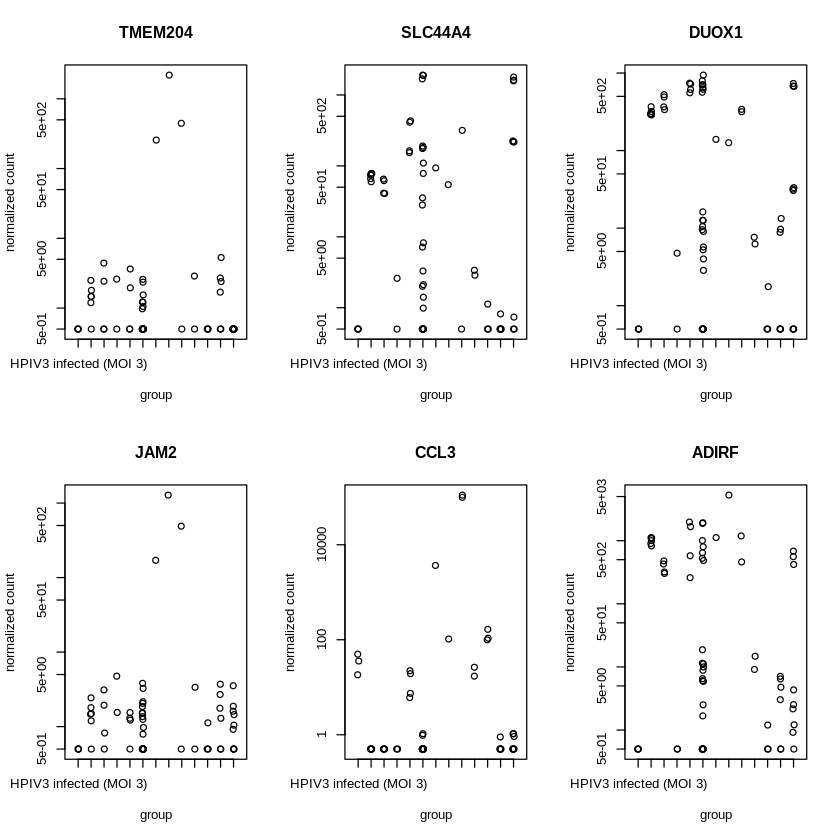

In [46]:
par(mfrow=c(2,3))

plotCounts(dds, gene="TMEM204", intgroup="treatment")
plotCounts(dds, gene="SLC44A4", intgroup="treatment")
plotCounts(dds, gene="DUOX1", intgroup="treatment")
plotCounts(dds, gene="JAM2", intgroup="treatment")
plotCounts(dds, gene="CCL3", intgroup="treatment")
plotCounts(dds, gene="ADIRF", intgroup="treatment")

Next steps in exploring these data...BLAST to database to find associated gene function

#Volcano Plot

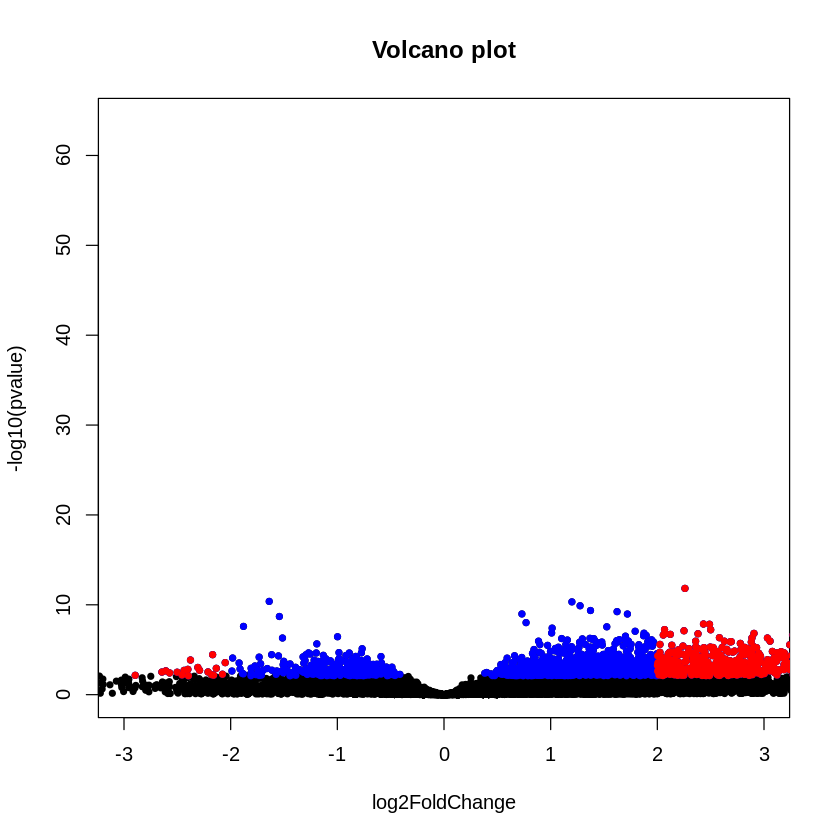

In [36]:
#reset par
par(mfrow=c(1,1))
# Make a basic volcano plot
with(res, plot(log2FoldChange, -log10(pvalue), pch=20, main="Volcano plot", xlim=c(-3,3)))

# Add colored points: blue if padj<0.01, red if log2FC>1 and padj<0.05)
with(subset(res, padj<.05 ), points(log2FoldChange, -log10(pvalue), pch=20, col="blue"))
with(subset(res, padj<.05 & abs(log2FoldChange)>2), points(log2FoldChange, -log10(pvalue), pch=20, col="red"))

#PCA
First we need to transform the raw count data vst function will perform variance stabilizing transformation

Using the DESEQ2 plotPCA fxn we can

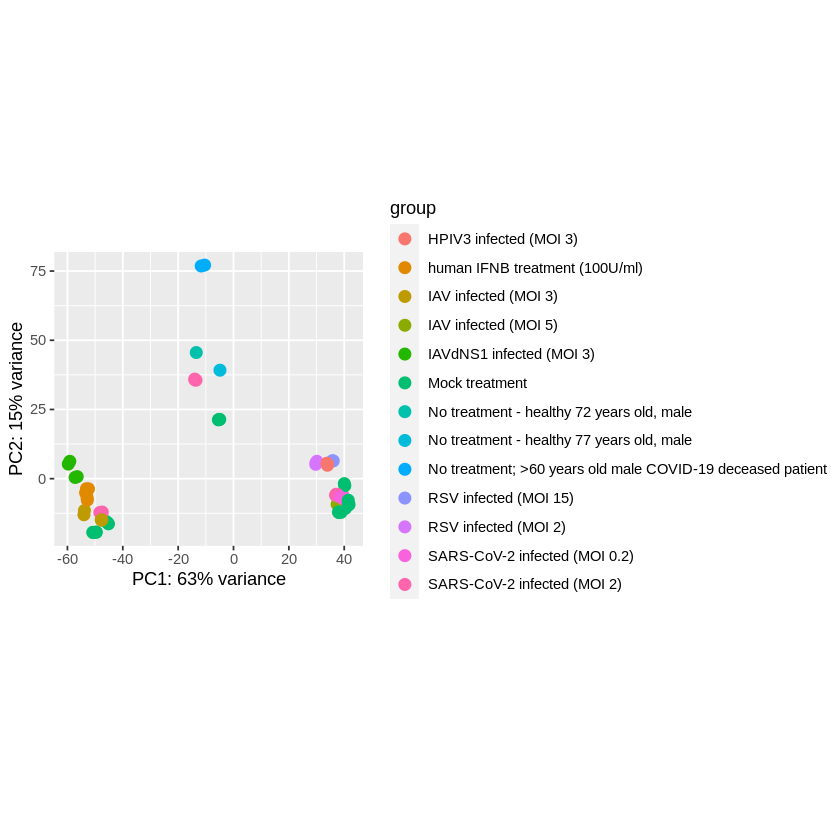

In [41]:
vsdata <- vst(dds, blind=FALSE)
plotPCA(vsdata, intgroup="treatment")

Extract results for the top 250 up-regulated and top 250 down-regulated genes, sorted by p-value:

Print results for top and bottom 5 genes

In [59]:
n = 250 
resOrdered <- results_omit_na[order(results_omit_na$padj),]
topResults <- rbind( resOrdered[ resOrdered[,'log2FoldChange'] > 0, ][1:n,], resOrdered[ resOrdered[,'log2FoldChange'] < 0, ][n:1,] )
topResults[c(1:5,(2*n-4):(2*n)), c('X','baseMean','log2FoldChange','padj')]

,X,baseMean,log2FoldChange,padj
,<chr>,<dbl>,<dbl>,<dbl>
17346,SLC44A4,205.81654,23.019106,1.107720e-17
6915,DUOX1,208.70188,21.698625,2.968766e-17
13347,JAM2,28.82435,13.632095,8.606278e-17
2620,ADIRF,421.97658,21.096064,3.659971e-16
18107,THBS2,80.99647,17.245417,3.659971e-16
4035,CHORDC1,696.76993,-1.879727,2.622383e-06
5541,HSPH1,1937.00165,-1.543327,2.811064e-07
20003,DNAJA1,3529.38696,-1.638537,8.181048e-09
8746,CCL3,3116.58778,-7.485643,1.070011e-16


Plot counts for a single gene. Below is the plot for the gene with the lowest p-value:

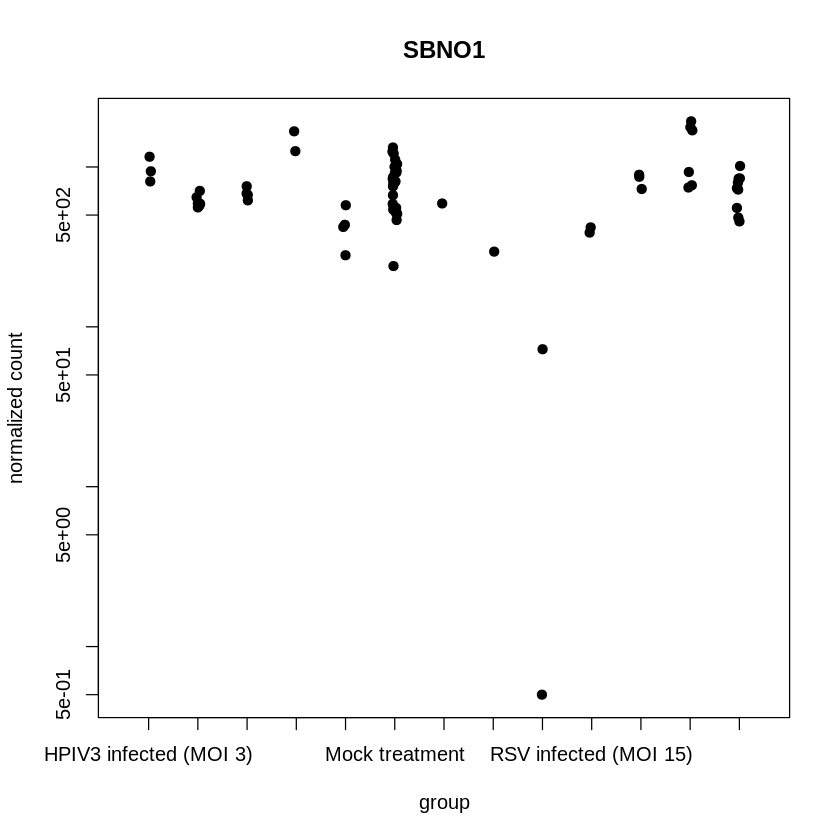

In [62]:
plotCounts(dds, gene=which.min(results_omit_na$padj), intgroup='treatment', pch = 19)